In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import h5py
import numpy as np
import cv2
from tqdm import tqdm
from skimage.feature import local_binary_pattern
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib


Mounted at /content/drive


In [ ]:
BASE = "/content/drive/MyDrive/morph_project"
PROC = os.path.join(BASE, "processed")
MODELS = os.path.join(BASE, "models")

train_h5 = h5py.File(os.path.join(PROC, "train.h5"), "r")
test_h5  = h5py.File(os.path.join(PROC, "test.h5"),  "r")

X_train_ds = train_h5["X"]
y_train_ds = train_h5["y"]
X_test_ds  = test_h5["X"]
y_test_ds  = test_h5["y"]

print("Train samples:", X_train_ds.shape[0])
print("Test samples:", X_test_ds.shape[0])


Train samples: 7177
Test samples: 1803


In [ ]:
from tqdm import tqdm
import numpy as np
import h5py
import os

BASE = "/content/drive/MyDrive/morph_project"
PROC = os.path.join(BASE, "processed")

train_h5 = h5py.File(os.path.join(PROC, "train.h5"), "r")
X_train_ds = train_h5["X"]

total_sum = 0.0
total_sum_sq = 0.0
total_count = 0

batch_size = 1000
n = X_train_ds.shape[0]

print("Computing global mean and std in streaming mode...")

for i in tqdm(range(0, n, batch_size)):
    batch = X_train_ds[i:i+batch_size]  # HDF5 slice, not loaded fully
    total_sum += batch.sum()
    total_sum_sq += (batch**2).sum()
    total_count += np.prod(batch.shape)

mean = total_sum / total_count
var = (total_sum_sq / total_count) - (mean**2)
std = np.sqrt(var)

print("Mean:", mean)
print("Std:", std)

np.savez(os.path.join(PROC, "stats.npz"), mean=mean, std=std)
print("Saved at:", os.path.join(PROC, "stats.npz"))


Computing global mean and std in streaming mode...


100%|██████████| 8/8 [01:06<00:00,  8.31s/it]

Mean: -2.633200133717971e-06
Std: 0.9996264772469634
Saved at: /content/drive/MyDrive/morph_project/processed/stats.npz


In [ ]:
stats = np.load(os.path.join(PROC, "stats.npz"))
mean = stats["mean"].item() if stats["mean"].shape == () else stats["mean"]
std  = stats["std"].item()  if stats["std"].shape  == () else stats["std"]

print("Mean:", mean)
print("Std:", std)


Mean: -2.633200133717971e-06
Std: 0.9996264772469634


In [ ]:
# Multi-scale LBP settings
SCALES = [(8,1), (16,2), (24,3)]

def lbp_histogram(gray, P, R):
    lbp = local_binary_pattern(gray, P=P, R=R, method="uniform")
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, P+3),
        range=(0, P+2),
        density=True
    )
    return hist.astype(np.float32)

def lbp_features_batch(images):
    # reverse standardization back to [0..1]
    images_01 = (images * (std + 1e-7)) + mean
    images_01 = np.clip(images_01, 0, 1)
    images_u8 = (images_01 * 255.0).astype(np.uint8)

    feats = []
    for img in images_u8:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        f = []
        for (P, R) in SCALES:
            f.append(lbp_histogram(gray, P, R))
        feats.append(np.concatenate(f))
    return np.array(feats)


In [ ]:
def extract_lbp_from_hdf5(X_ds, batch_size=500):
    n = X_ds.shape[0]
    X_feats = []
    for i in tqdm(range(0, n, batch_size)):
        batch = X_ds[i:i+batch_size]
        feats = lbp_features_batch(batch)
        X_feats.append(feats)
    return np.concatenate(X_feats, axis=0)

X_train_lbp = extract_lbp_from_hdf5(X_train_ds, batch_size=500)
X_test_lbp  = extract_lbp_from_hdf5(X_test_ds, batch_size=500)

y_train = np.array(y_train_ds, dtype=np.int32)
y_test  = np.array(y_test_ds, dtype=np.int32)

print("Train LBP shape:", X_train_lbp.shape)
print("Test LBP shape:", X_test_lbp.shape)


100%|██████████| 4/4 [02:15<00:00, 34.00s/it]

Train LBP shape: (7177, 54)
Test LBP shape: (1803, 54)


In [24]:
X_train_lbp = extract_lbp_from_hdf5(X_train_ds, batch_size=500)
X_test_lbp  = extract_lbp_from_hdf5(X_test_ds, batch_size=500)

y_train = np.array(y_train_ds, dtype=np.int32)
y_test  = np.array(y_test_ds, dtype=np.int32)

print("Train LBP shape:", X_train_lbp.shape)
print("Test LBP shape:", X_test_lbp.shape)

# -----------------------------------------------------------
# ✅ ADD THIS PART HERE (Improved RF with SMOTE+ENN)
from imblearn.combine import SMOTEENN

sampler = SMOTEENN(random_state=42)
print("Balancing dataset using SMOTE+ENN...")
X_train_balanced, y_train_balanced = sampler.fit_resample(X_train_lbp, y_train)

print("Before balancing:", np.bincount(y_train))
print("After balancing :", np.bincount(y_train_balanced))

# ✅ Improved Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight={0:1, 1:4},  # penalize mistakes on Tp class
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_balanced, y_train_balanced)

pred = rf.predict(X_test_lbp)
acc = accuracy_score(y_test, pred)

print("Improved RF Accuracy:", acc)
print(classification_report(y_test, pred, target_names=["Au","Tp"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))
# -----------------------------------------------------------


100%|██████████| 4/4 [02:24<00:00, 36.15s/it]


Train LBP shape: (7177, 54)
Test LBP shape: (1803, 54)
Balancing dataset using SMOTE+ENN...
Before balancing: [5946 1231]
After balancing : [2669 5157]
Improved RF Accuracy: 0.4437049362174154
              precision    recall  f1-score   support

          Au       0.91      0.36      0.52      1489
          Tp       0.22      0.83      0.34       314

    accuracy                           0.44      1803
   macro avg       0.56      0.60      0.43      1803
weighted avg       0.79      0.44      0.49      1803

Confusion Matrix:
[[539 950]
 [ 53 261]]


In [51]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight = len(y_train)/sum(y_train==1),  # imbalance handling
    eval_metric='logloss'
)

print("Training XGBoost...")
xgb.fit(X_train_lbp, y_train)

probs = xgb.predict_proba(X_test_lbp)[:,1]
pred = (probs >= 0.5).astype(int)

print("XGBoost Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=["Au","Tp"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))


Training XGBoost...
XGBoost Accuracy: 0.817526344980588
              precision    recall  f1-score   support

          Au       0.85      0.95      0.90      1489
          Tp       0.45      0.21      0.28       314

    accuracy                           0.82      1803
   macro avg       0.65      0.58      0.59      1803
weighted avg       0.78      0.82      0.79      1803

Confusion Matrix:
[[1409   80]
 [ 249   65]]


In [52]:
probs = xgb.predict_proba(X_test_lbp)[:,1]

for t in [0.3, 0.35, 0.4, 0.45, 0.5]:
    pred_t = (probs >= t).astype(int)
    print("Threshold:", t,
          "| Accuracy:", accuracy_score(y_test, pred_t))
    print(classification_report(y_test, pred_t,
          target_names=["Au","Tp"]))


Threshold: 0.3 | Accuracy: 0.7870216306156406
              precision    recall  f1-score   support

          Au       0.86      0.89      0.87      1489
          Tp       0.37      0.32      0.34       314

    accuracy                           0.79      1803
   macro avg       0.62      0.60      0.61      1803
weighted avg       0.78      0.79      0.78      1803

Threshold: 0.35 | Accuracy: 0.8019966722129783
              precision    recall  f1-score   support

          Au       0.86      0.91      0.88      1489
          Tp       0.41      0.30      0.35       314

    accuracy                           0.80      1803
   macro avg       0.63      0.60      0.62      1803
weighted avg       0.78      0.80      0.79      1803

Threshold: 0.4 | Accuracy: 0.8069883527454242
              precision    recall  f1-score   support

          Au       0.86      0.92      0.89      1489
          Tp       0.42      0.27      0.33       314

    accuracy                           0.81

In [53]:
print(classification_report(y_test, pred, target_names=["Au","Tp"]))
print(confusion_matrix(y_test, pred))


              precision    recall  f1-score   support

          Au       0.85      0.95      0.90      1489
          Tp       0.45      0.21      0.28       314

    accuracy                           0.82      1803
   macro avg       0.65      0.58      0.59      1803
weighted avg       0.78      0.82      0.79      1803

[[1409   80]
 [ 249   65]]


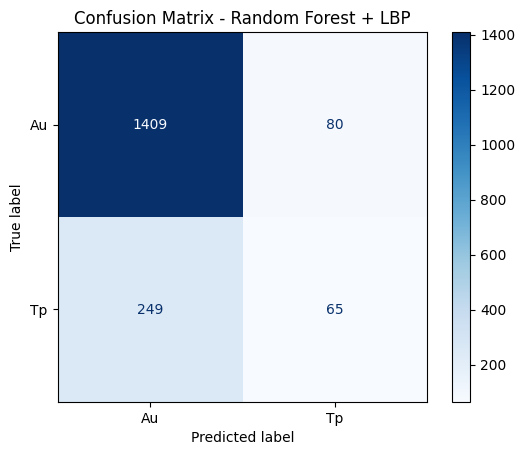

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Au", "Tp"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest + LBP")
plt.show()


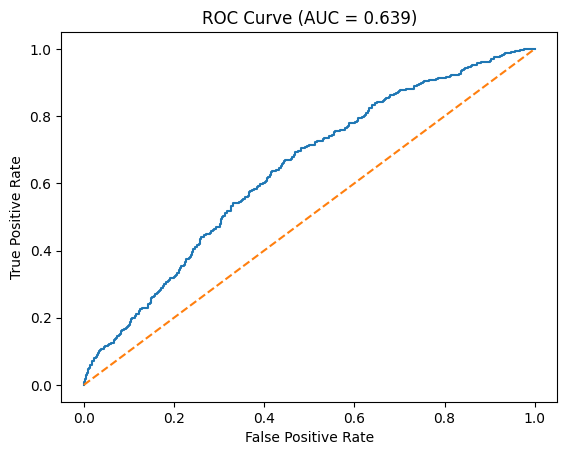

In [27]:
from sklearn.metrics import roc_curve, auc

probs = rf.predict_proba(X_test_lbp)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {round(auc_score,3)})")
plt.show()


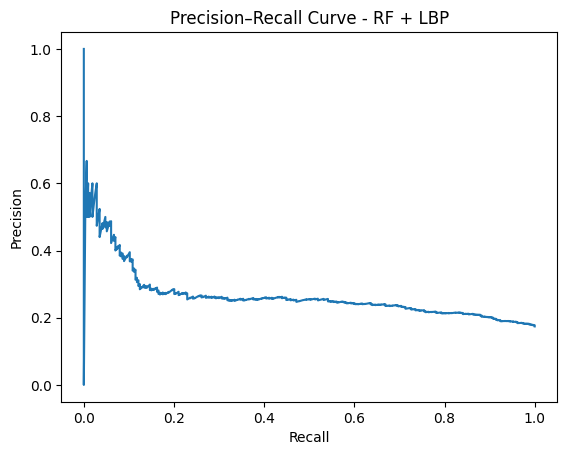

In [28]:
from sklearn.metrics import precision_recall_curve

precision, recall, thr = precision_recall_curve(y_test, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - RF + LBP")
plt.show()


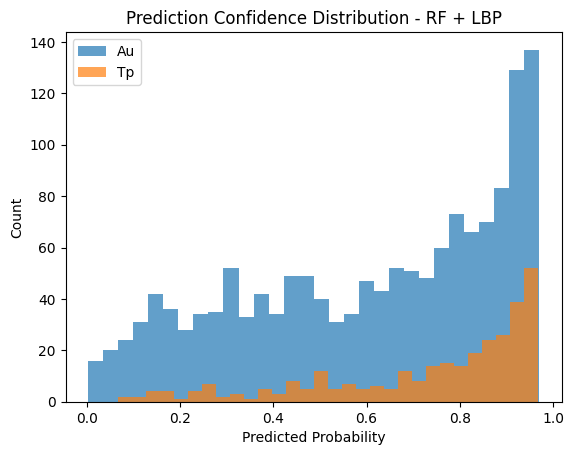

In [29]:
plt.hist(probs[y_test==0], bins=30, alpha=0.7, label="Au")
plt.hist(probs[y_test==1], bins=30, alpha=0.7, label="Tp")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Prediction Confidence Distribution - RF + LBP")
plt.legend()
plt.show()


In [32]:
import joblib

MODEL_PATH = "/content/drive/MyDrive/morph_project/models/rf_lbp_model_v2.pkl"
joblib.dump(rf, MODEL_PATH)

print("Saved improved model at:", MODEL_PATH)



Saved improved model at: /content/drive/MyDrive/morph_project/models/rf_lbp_model_v2.pkl


In [33]:
from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import joblib
import numpy as np
from skimage.feature import local_binary_pattern
from google.colab import files

BASE = "/content/drive/MyDrive/morph_project"
PROC = os.path.join(BASE, "processed")
MODEL_PATH = "/content/drive/MyDrive/morph_project/models/rf_lbp_model_v2.pkl"   # NEW MODEL

stats = np.load(os.path.join(PROC, "stats.npz"))
mean = stats["mean"].item() if stats["mean"].shape == () else stats["mean"]
std  = stats["std"].item()  if stats["std"].shape  == () else stats["std"]

SCALES = [(8,1), (16,2), (24,3)]

def lbp_histogram(gray, P, R):
    lbp = local_binary_pattern(gray, P=P, R=R, method="uniform")
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, P+3),
        range=(0, P+2),
        density=True
    )
    return hist.astype(np.float32)

def lbp_features_batch(images):
    images_01 = (images * (std + 1e-7)) + mean
    images_01 = np.clip(images_01, 0, 1)
    images_u8 = (images_01 * 255.0).astype(np.uint8)

    feats = []
    for img in images_u8:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        f = []
        for (P, R) in SCALES:
            f.append(lbp_histogram(gray, P, R))
        feats.append(np.concatenate(f))
    return np.array(feats)

def predict_uploaded_image():
    uploaded = files.upload()
    for fname in uploaded.keys():
        print("Uploaded:", fname)

        img_bgr = cv2.imread(fname)
        if img_bgr is None:
            print("Could not read image.")
            continue

        img = cv2.resize(img_bgr, (224,224))
        img = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

        img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
        img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
        img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

        img = img.astype(np.float32) / 255.0
        img = (img - mean) / (std + 1e-7)

        feats = lbp_features_batch(img[np.newaxis,...])
        model = joblib.load(MODEL_PATH)

        pred = model.predict(feats)[0]
        prob = model.predict_proba(feats).max()

        print("Prediction:", ["Au","Tp"][pred])
        print("Confidence:", round(prob*100, 2), "%")

predict_uploaded_image()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving casias1.png to casias1 (2).png
Uploaded: casias1 (2).png
Prediction: Au
Confidence: 69.21 %


In [34]:
probs = rf.predict_proba(X_test_lbp)[:,1]


In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

thresholds = [0.10, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50]

for t in thresholds:
    pred_t = (probs >= t).astype(int)
    acc = accuracy_score(y_test, pred_t)
    print(f"Threshold: {t}  | Accuracy: {acc:.3f}")


Threshold: 0.1  | Accuracy: 0.206
Threshold: 0.2  | Accuracy: 0.263
Threshold: 0.3  | Accuracy: 0.314
Threshold: 0.35  | Accuracy: 0.349
Threshold: 0.4  | Accuracy: 0.375
Threshold: 0.45  | Accuracy: 0.411
Threshold: 0.5  | Accuracy: 0.444


In [36]:
thresholds = [0.55, 0.6, 0.65, 0.7, 0.75, 0.8]

for t in thresholds:
    pred_t = (probs >= t).astype(int)
    acc = accuracy_score(y_test, pred_t)
    print(f"Threshold: {t}  | Accuracy: {acc:.3f}")


Threshold: 0.55  | Accuracy: 0.466
Threshold: 0.6  | Accuracy: 0.495
Threshold: 0.65  | Accuracy: 0.527
Threshold: 0.7  | Accuracy: 0.563
Threshold: 0.75  | Accuracy: 0.595
Threshold: 0.8  | Accuracy: 0.639


In [37]:
best_t = 0.80
pred_best = (probs >= best_t).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, pred_best, target_names=["Au","Tp"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_best))


              precision    recall  f1-score   support

          Au       0.87      0.66      0.75      1489
          Tp       0.25      0.54      0.34       314

    accuracy                           0.64      1803
   macro avg       0.56      0.60      0.55      1803
weighted avg       0.76      0.64      0.68      1803

Confusion Matrix:
[[983 506]
 [144 170]]


In [48]:
pred_thresh = (probs >= 0.75).astype(int)


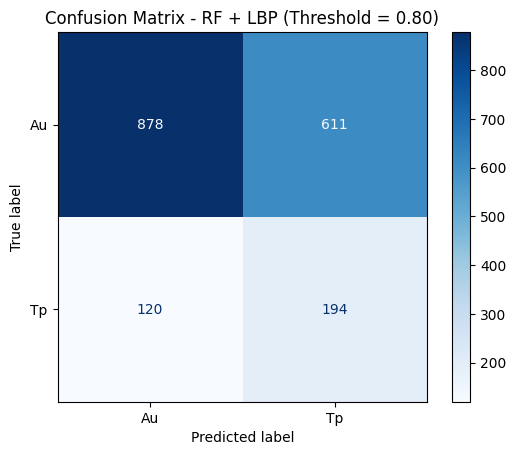

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_thresh)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Au", "Tp"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - RF + LBP (Threshold = 0.80)")
plt.show()
